In [2]:
import os
from google.colab import drive
from getpass import getpass
drive.mount('/content/drive')

os.environ["KAGGLE_USERNAME"] = getpass("Kaggle username: ").strip()
os.environ["KAGGLE_KEY"] = getpass("Kaggle API key: ").strip()

!pip install -q kaggle
!kaggle datasets download -d jessicali9530/celeba-dataset
!unzip -q celeba-dataset.zip -d celeba
print("Dataset đã được tải và giải nén")

import glob
orig_images = glob.glob('celeba/img_align_celeba/img_align_celeba/*.jpg')
print(f"Số lượng ảnh gốc: {len(orig_images)}")

img_dir = 'celeba/img_align_celeba/img_align_celeba'
sample_images = glob.glob(f'{img_dir}/*.jpg')[:5]
print(f"\n Ảnh mẫu:")
for img in sample_images:
    print(f"   - {os.path.basename(img)}")


Mounted at /content/drive
Kaggle username: ··········
Kaggle API key: ··········
Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
100% 1.33G/1.33G [01:18<00:00, 18.3MB/s]

Dataset đã được tải và giải nén
Số lượng ảnh gốc: 202599

 Ảnh mẫu:
   - 139945.jpg
   - 089570.jpg
   - 034660.jpg
   - 022347.jpg
   - 119333.jpg


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.utils as vutils
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import pandas as pd
from tqdm import tqdm
# CHuẩn bị nhãn giới tính cho COnditional GAN
# Đọc file attribute
df_attr = pd.read_csv('celeba/list_attr_celeba.csv')

# Chuyển -1 thành 0 (vì -1 là nữ, 1 là nam trong CelebA)
# Nhưng theo yêu cầu: Male=1 là nam
df_attr['Male'] = df_attr['Male'].replace(-1, 0)

# Tạo dictionary mapping từ filename -> gender
attr_dict = dict(zip(df_attr['image_id'], df_attr['Male']))

# Kiểm tra
print(f"Số lượng ảnh có nhãn: {len(attr_dict)}")
print(f"Tỉ lệ nam: {df_attr['Male'].sum() / len(df_attr) * 100:.1f}%")
print(f"Tỉ lệ nữ: {(len(df_attr) - df_attr['Male'].sum()) / len(df_attr) * 100:.1f}%")

Số lượng ảnh có nhãn: 202599
Tỉ lệ nam: 41.7%
Tỉ lệ nữ: 58.3%


 Dataset GAN: 202599 ảnh, 1582 batches
 Dataset cGAN: 202599 ảnh, 1582 batches
VD mẫu ảnh: torch.Size([128, 3, 64, 64])


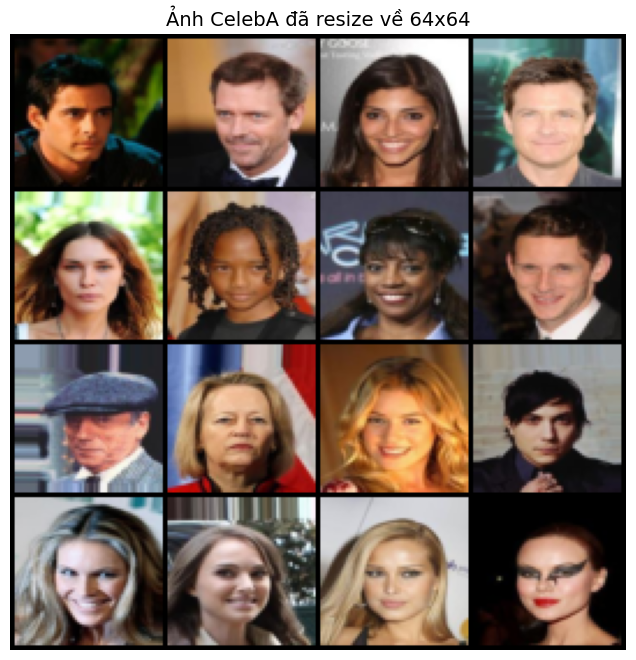

In [9]:
# Xây dựng dataset và Dataloader
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torch

class FaceDataset(Dataset):
    def __init__(self, img_dir, attr_dict=None, transform=None, conditional=False):
        self.img_paths = list(Path(img_dir).glob('*.jpg'))
        self.transform = transform
        self.conditional = conditional
        self.attr_dict = attr_dict if conditional else None

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)

        if self.conditional:
            # Lấy nhãn giới tính
            filename = self.img_paths[idx].name
            label = self.attr_dict.get(filename, 0)
            return img, torch.tensor(label, dtype=torch.long)
        else:
            return img

# Transform cho GAN (normalize về [-1, 1])
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

img_dir = 'celeba/img_align_celeba/img_align_celeba'

# Dataset cho GAN thường
dataset_gan = FaceDataset(img_dir, transform=transform, conditional=False)
dataloader_gan = DataLoader(dataset_gan, batch_size=128, shuffle=True,
                            drop_last=True, num_workers=2)

# Dataset cho Conditional GAN
dataset_cgan = FaceDataset(img_dir, attr_dict, transform, conditional=True)
dataloader_cgan = DataLoader(dataset_cgan, batch_size=128, shuffle=True,
                             drop_last=True, num_workers=2)

print(f" Dataset GAN: {len(dataset_gan)} ảnh, {len(dataloader_gan)} batches")
print(f" Dataset cGAN: {len(dataset_cgan)} ảnh, {len(dataloader_cgan)} batches")

# Hiển thị mẫu ảnh
sample_imgs = next(iter(dataloader_gan))
print(f"VD mẫu ảnh: {sample_imgs.shape}")

grid = vutils.make_grid(sample_imgs[:16], nrow=4, normalize=True)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).numpy())
plt.axis('off')
plt.title('Ảnh CelebA đã resize về 64x64', fontsize=14)
plt.show()


3 Xây dựng GAN tự viết theo yêu cầu

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.utils as vutils
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

class Generator(nn.Module):
    def __init__(self, z_dim=100, ngf=64):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(z_dim, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8), nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4), nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2), nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf), nn.ReLU(True),
            nn.ConvTranspose2d(ngf, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.main(z)

class Discriminator(nn.Module):
    def __init__(self, ndf=64):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(3, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        out = self.main(x)
        out = out.reshape(out.size(0), -1)  # (batch, 1) -> (batch,)
        out = out.squeeze(1)  # Xóa chiều thứ 2
        return out

# Khởi tạo model
z_dim = 100
G = Generator(z_dim).to(device)
D = Discriminator().to(device)

print(f" Model khởi tạo thành công.")
print(f"   Generator: {sum(p.numel() for p in G.parameters())/1e6:.2f}M params")
print(f"   Discriminator: {sum(p.numel() for p in D.parameters())/1e6:.2f}M params")

# KIỂM TRA SHAPE
test_input = torch.randn(4, 3, 64, 64).to(device)
test_output = D(test_input)
print(f"\n TEST DISCRIMINATOR OUTPUT SHAPE:")
print(f"   Input shape: {test_input.shape}")
print(f"   Output shape: {test_output.shape}")
print(f"   Expected: torch.Size([4])")

if test_output.shape == torch.Size([4]):
    print("  Shape đúng. Bắt đầu train được.")
else:
    print(f"  Lỗi, {test_output.shape}, expected torch.Size([4])")

Device: cuda
 Model khởi tạo thành công.
   Generator: 3.58M params
   Discriminator: 2.77M params

 TEST DISCRIMINATOR OUTPUT SHAPE:
   Input shape: torch.Size([4, 3, 64, 64])
   Output shape: torch.Size([4])
   Expected: torch.Size([4])
  Shape đúng. Bắt đầu train được.


In [11]:
#  Khởi tạo optimizer và loss function
import torch.optim as optim

criterion = nn.BCELoss()
optimizer_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

fixed_noise = torch.randn(64, z_dim, 1, 1, device=device)
G_losses, D_losses = [], []

Epoch 1/15: 100%|██████████| 1582/1582 [04:42<00:00,  5.59it/s]


 Epoch 1: D_loss=0.7091, G_loss=3.7749


Epoch 2/15: 100%|██████████| 1582/1582 [04:41<00:00,  5.62it/s]


 Epoch 2: D_loss=0.6296, G_loss=3.2679


Epoch 3/15: 100%|██████████| 1582/1582 [04:40<00:00,  5.65it/s]


 Epoch 3: D_loss=0.5969, G_loss=3.1833


Epoch 4/15: 100%|██████████| 1582/1582 [04:41<00:00,  5.63it/s]


 Epoch 4: D_loss=0.5044, G_loss=3.4239


Epoch 5/15: 100%|██████████| 1582/1582 [04:39<00:00,  5.65it/s]


 Epoch 5: D_loss=0.4562, G_loss=3.6460


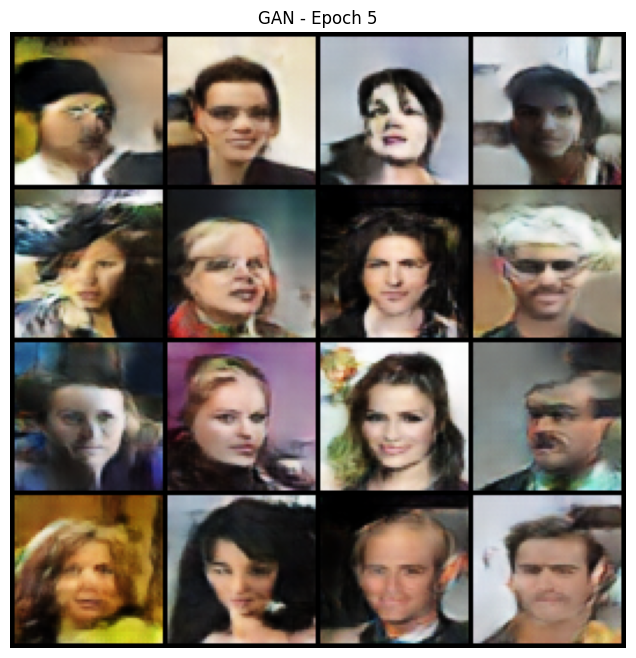

Epoch 6/15: 100%|██████████| 1582/1582 [04:48<00:00,  5.49it/s]


 Epoch 6: D_loss=0.4223, G_loss=3.8158


Epoch 7/15: 100%|██████████| 1582/1582 [04:49<00:00,  5.46it/s]


 Epoch 7: D_loss=0.3786, G_loss=4.0186


Epoch 8/15: 100%|██████████| 1582/1582 [04:48<00:00,  5.48it/s]


 Epoch 8: D_loss=0.3625, G_loss=4.0756


Epoch 9/15: 100%|██████████| 1582/1582 [04:48<00:00,  5.49it/s]


 Epoch 9: D_loss=0.3397, G_loss=4.2130


Epoch 10/15: 100%|██████████| 1582/1582 [04:46<00:00,  5.52it/s]


 Epoch 10: D_loss=0.3146, G_loss=4.3503


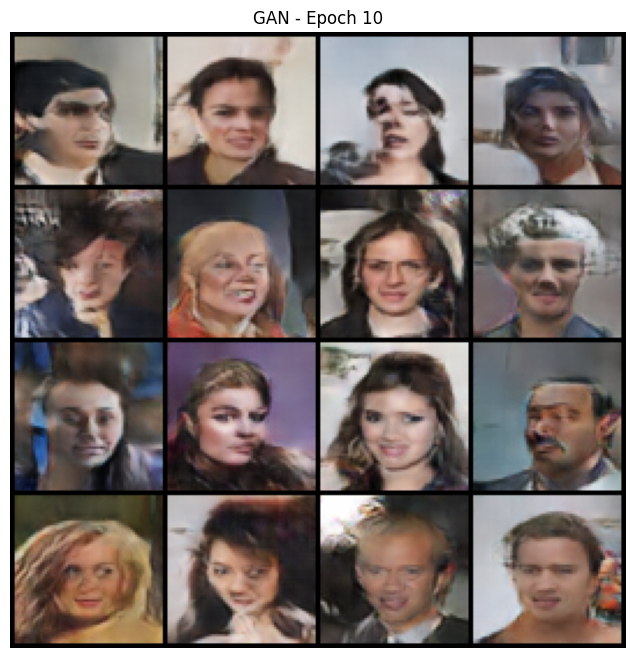

Epoch 11/15: 100%|██████████| 1582/1582 [04:50<00:00,  5.44it/s]


 Epoch 11: D_loss=0.3242, G_loss=4.3754


Epoch 12/15: 100%|██████████| 1582/1582 [04:50<00:00,  5.45it/s]


 Epoch 12: D_loss=0.3016, G_loss=4.6416


Epoch 13/15: 100%|██████████| 1582/1582 [04:49<00:00,  5.46it/s]


 Epoch 13: D_loss=0.2887, G_loss=4.5863


Epoch 14/15: 100%|██████████| 1582/1582 [04:50<00:00,  5.44it/s]


 Epoch 14: D_loss=0.2970, G_loss=4.5855


Epoch 15/15: 100%|██████████| 1582/1582 [04:51<00:00,  5.43it/s]


 Epoch 15: D_loss=0.2757, G_loss=4.8083


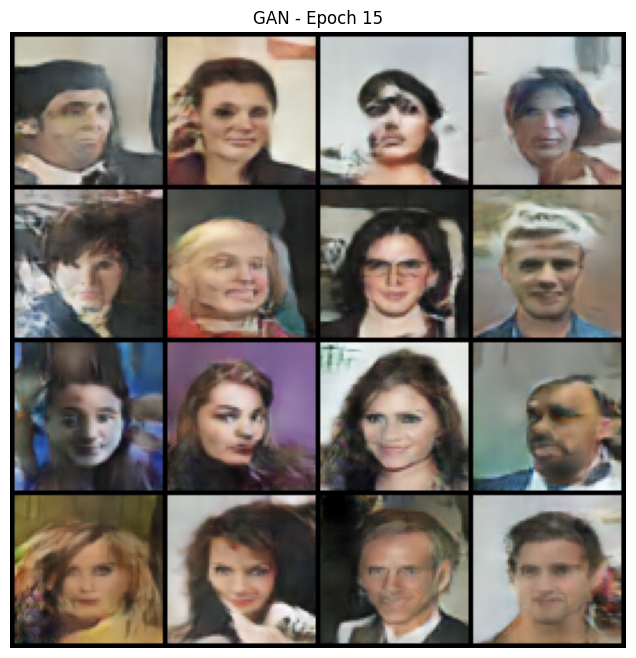

In [12]:
from tqdm import tqdm
import matplotlib.pyplot as plt
import torchvision.utils as vutils
num_epochs = 15
for epoch in range(num_epochs):
    epoch_G_loss = 0
    epoch_D_loss = 0

    for i, real_imgs in enumerate(tqdm(dataloader_gan, desc=f"Epoch {epoch+1}/{num_epochs}")):
        real_imgs = real_imgs.to(device)
        batch_size = real_imgs.size(0)

        # Labels
        real_labels = torch.ones(batch_size, device=device)
        fake_labels = torch.zeros(batch_size, device=device)

        # Train Discriminator
        optimizer_D.zero_grad()

        # Loss với ảnh thật
        output_real = D(real_imgs)
        loss_real = criterion(output_real, real_labels)

        # Loss với ảnh giả
        noise = torch.randn(batch_size, z_dim, 1, 1, device=device)
        fake_imgs = G(noise)
        output_fake = D(fake_imgs.detach())
        loss_fake = criterion(output_fake, fake_labels)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        optimizer_D.step()

        #  Train Generator
        optimizer_G.zero_grad()

        output_fake = D(fake_imgs)
        loss_G = criterion(output_fake, real_labels)
        loss_G.backward()
        optimizer_G.step()

        epoch_G_loss += loss_G.item()
        epoch_D_loss += loss_D.item()

    # Tính loss trung bình
    avg_G_loss = epoch_G_loss / len(dataloader_gan)
    avg_D_loss = epoch_D_loss / len(dataloader_gan)
    G_losses.append(avg_G_loss)
    D_losses.append(avg_D_loss)

    print(f" Epoch {epoch+1}: D_loss={avg_D_loss:.4f}, G_loss={avg_G_loss:.4f}")

    # Hiển thị ảnh mẫu mỗi 5 epochs
    if (epoch + 1) % 5 == 0:
        with torch.no_grad():
            samples = G(fixed_noise).cpu()
        grid = vutils.make_grid(samples[:16], nrow=4, normalize=True)
        plt.figure(figsize=(8, 8))
        plt.imshow(grid.permute(1, 2, 0).numpy())
        plt.axis('off')
        plt.title(f'GAN - Epoch {epoch+1}')
        plt.show()


# Conditional GAN

In [13]:
# Conditional Generator và Discriminator
class CondGenerator(nn.Module):
    def __init__(self, z_dim=100, num_classes=2, embed_size=50, ngf=64):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, embed_size)

        # Input: z_dim + embed_size
        self.main = nn.Sequential(
            nn.ConvTranspose2d(z_dim + embed_size, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z, labels):
        # Nhúng label và reshape
        label_embed = self.label_emb(labels).view(-1, 50, 1, 1)
        # Concatenate với noise
        z_combined = torch.cat([z, label_embed], dim=1)
        return self.main(z_combined)

class CondDiscriminator(nn.Module):
    def __init__(self, num_classes=2, ndf=64):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, 64 * 64)  # Embed thành 4096 số

        self.main = nn.Sequential(
            # Input: 3 + 1 (label map) = 4 channels
            nn.Conv2d(4, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        # Nhúng label và reshape thành bản đồ 64x64
        label_map = self.label_emb(labels).view(-1, 1, 64, 64)
        # Concatenate với ảnh
        combined = torch.cat([img, label_map], dim=1)
        return self.main(combined).view(-1)

cGAN Epoch 1: 100%|██████████| 1582/1582 [05:06<00:00,  5.16it/s]


cGAN Epoch 1: D_loss=0.7247, G_loss=4.4035


cGAN Epoch 2: 100%|██████████| 1582/1582 [05:00<00:00,  5.26it/s]


cGAN Epoch 2: D_loss=0.7472, G_loss=3.7417


cGAN Epoch 3: 100%|██████████| 1582/1582 [05:00<00:00,  5.26it/s]


cGAN Epoch 3: D_loss=0.7427, G_loss=3.4581


cGAN Epoch 4: 100%|██████████| 1582/1582 [05:01<00:00,  5.24it/s]


cGAN Epoch 4: D_loss=0.6414, G_loss=3.2703


cGAN Epoch 5: 100%|██████████| 1582/1582 [05:00<00:00,  5.27it/s]


cGAN Epoch 5: D_loss=0.5975, G_loss=3.1482


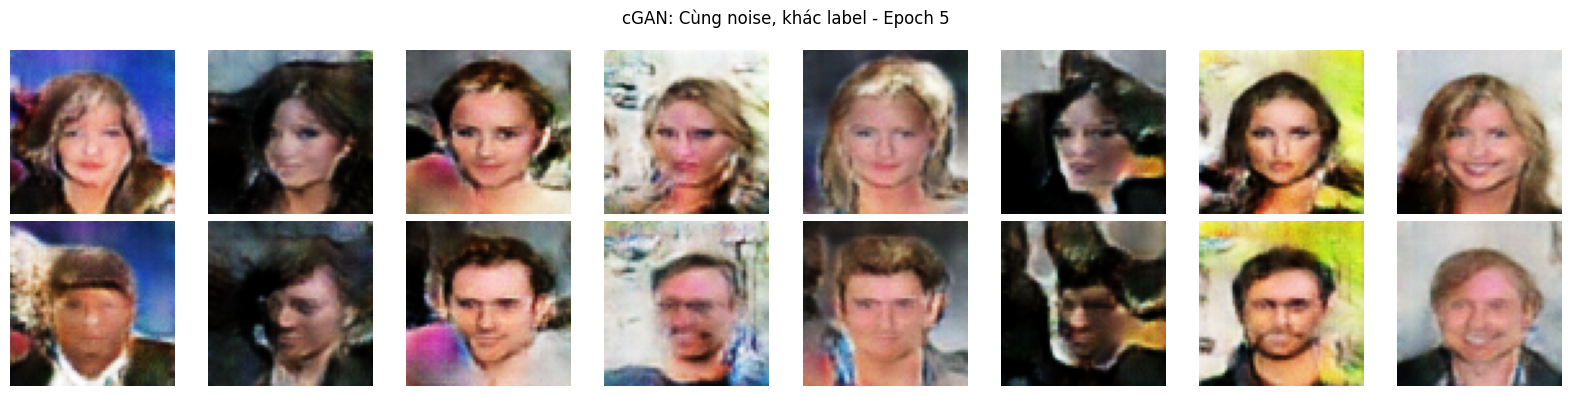

cGAN Epoch 6: 100%|██████████| 1582/1582 [05:07<00:00,  5.14it/s]


cGAN Epoch 6: D_loss=0.5043, G_loss=3.4559


cGAN Epoch 7: 100%|██████████| 1582/1582 [05:07<00:00,  5.15it/s]


cGAN Epoch 7: D_loss=0.4546, G_loss=3.6894


cGAN Epoch 8: 100%|██████████| 1582/1582 [05:07<00:00,  5.14it/s]


cGAN Epoch 8: D_loss=0.3924, G_loss=3.8858


cGAN Epoch 9: 100%|██████████| 1582/1582 [05:05<00:00,  5.17it/s]


cGAN Epoch 9: D_loss=0.3712, G_loss=4.0088


cGAN Epoch 10: 100%|██████████| 1582/1582 [05:08<00:00,  5.13it/s]


cGAN Epoch 10: D_loss=0.3445, G_loss=4.0721


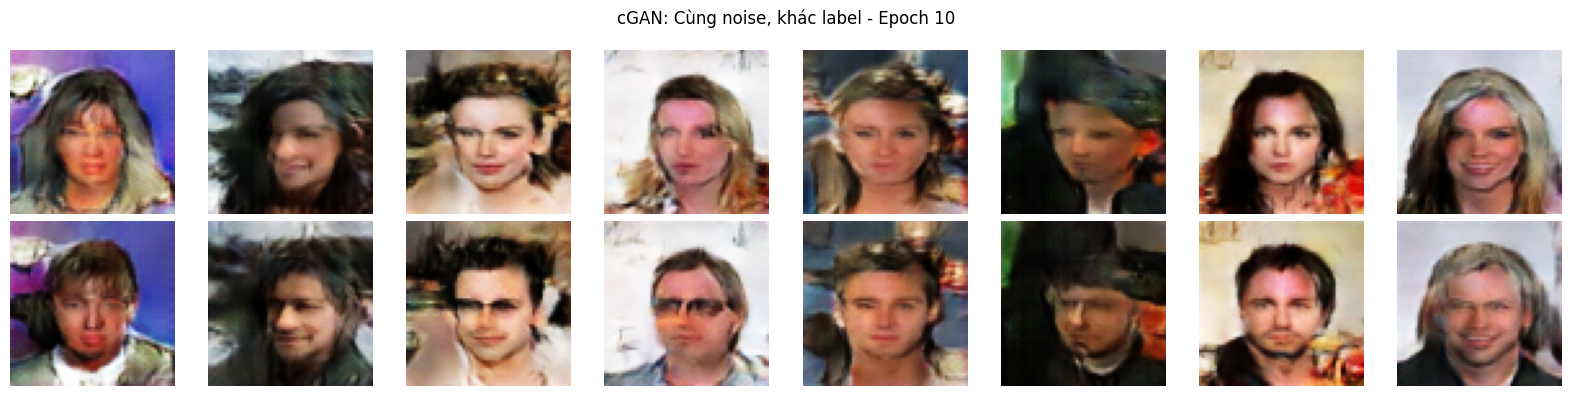

cGAN Epoch 11: 100%|██████████| 1582/1582 [05:09<00:00,  5.11it/s]


cGAN Epoch 11: D_loss=0.3440, G_loss=4.1355


cGAN Epoch 12: 100%|██████████| 1582/1582 [05:10<00:00,  5.09it/s]


cGAN Epoch 12: D_loss=0.3154, G_loss=4.2893


cGAN Epoch 13: 100%|██████████| 1582/1582 [05:10<00:00,  5.10it/s]


cGAN Epoch 13: D_loss=0.3086, G_loss=4.2429


cGAN Epoch 14: 100%|██████████| 1582/1582 [05:09<00:00,  5.12it/s]


cGAN Epoch 14: D_loss=0.3183, G_loss=4.3474


cGAN Epoch 15: 100%|██████████| 1582/1582 [05:10<00:00,  5.10it/s]


cGAN Epoch 15: D_loss=0.2636, G_loss=4.4717


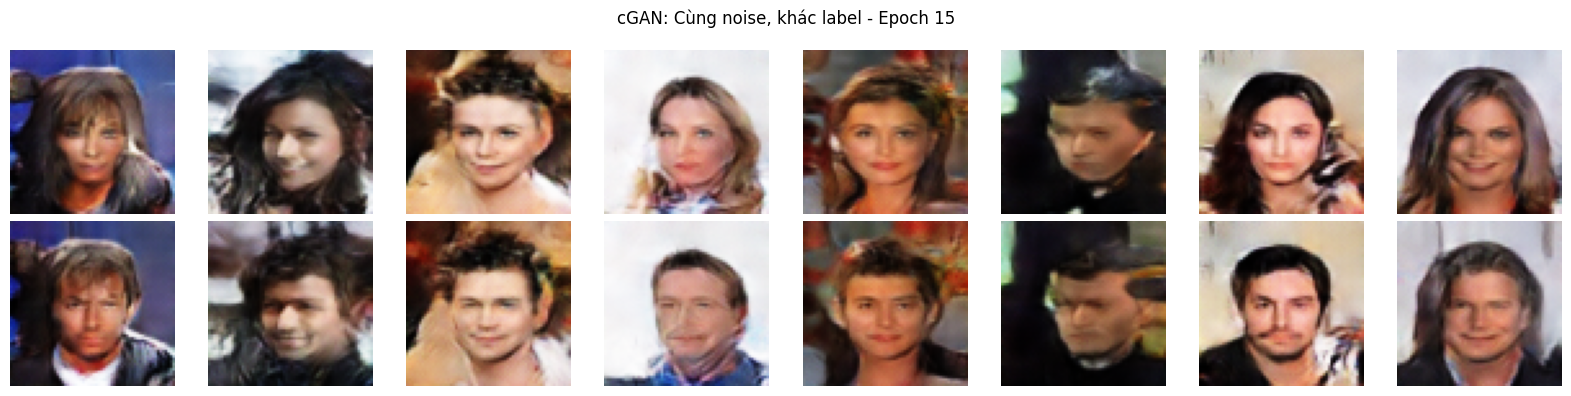

In [14]:
# Training cGAN
cG = CondGenerator(z_dim).to(device)
cD = CondDiscriminator().to(device)

optimizer_cG = optim.Adam(cG.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_cD = optim.Adam(cD.parameters(), lr=0.0002, betas=(0.5, 0.999))

# Fixed noise để demo
fixed_noise_c = torch.randn(8, z_dim, 1, 1, device=device)
fixed_labels_female = torch.zeros(8, dtype=torch.long, device=device)
fixed_labels_male = torch.ones(8, dtype=torch.long, device=device)

cG_losses, cD_losses = [], []

for epoch in range(15):
    epoch_G_loss = 0
    epoch_D_loss = 0

    for i, (real_imgs, labels) in enumerate(tqdm(dataloader_cgan, desc=f"cGAN Epoch {epoch+1}")):
        real_imgs = real_imgs.to(device)
        labels = labels.to(device)
        batch_size = real_imgs.size(0)

        real_labels_vec = torch.ones(batch_size, device=device)
        fake_labels_vec = torch.zeros(batch_size, device=device)

        # Train Discriminator
        optimizer_cD.zero_grad()

        # Real images
        output_real = cD(real_imgs, labels)
        loss_real = criterion(output_real, real_labels_vec)

        # Fake images
        noise = torch.randn(batch_size, z_dim, 1, 1, device=device)
        fake_imgs = cG(noise, labels)
        output_fake = cD(fake_imgs.detach(), labels)
        loss_fake = criterion(output_fake, fake_labels_vec)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        optimizer_cD.step()

        # Train Generator
        optimizer_cG.zero_grad()

        output_fake = cD(fake_imgs, labels)
        loss_G = criterion(output_fake, real_labels_vec)
        loss_G.backward()
        optimizer_cG.step()

        epoch_G_loss += loss_G.item()
        epoch_D_loss += loss_D.item()

    avg_G = epoch_G_loss / len(dataloader_cgan)
    avg_D = epoch_D_loss / len(dataloader_cgan)
    cG_losses.append(avg_G)
    cD_losses.append(avg_D)

    print(f"cGAN Epoch {epoch+1}: D_loss={avg_D:.4f}, G_loss={avg_G:.4f}")

    # Demo: cùng noise khác label
    if (epoch + 1) % 5 == 0:
        with torch.no_grad():
            fake_female = cG(fixed_noise_c, fixed_labels_female).cpu()
            fake_male = cG(fixed_noise_c, fixed_labels_male).cpu()

        # Hiển thị so sánh
        fig, axes = plt.subplots(2, 8, figsize=(16, 4))
        for i in range(8):
            axes[0, i].imshow((fake_female[i].permute(1, 2, 0).numpy() + 1) / 2)
            axes[0, i].axis('off')
            axes[1, i].imshow((fake_male[i].permute(1, 2, 0).numpy() + 1) / 2)
            axes[1, i].axis('off')
        axes[0, 0].set_ylabel('Female', fontsize=12)
        axes[1, 0].set_ylabel('Male', fontsize=12)
        plt.suptitle(f'cGAN: Cùng noise, khác label - Epoch {epoch+1}')
        plt.tight_layout()
        plt.show()

# WGAN với Gradient Penalty

In [15]:
# Xây dựng WGAN-GP
class WGAN_Generator(nn.Module):
    """Giống Generator cơ bản nhưng không thay đổi"""
    def __init__(self, z_dim=100, ngf=64):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(z_dim, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8), nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4), nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2), nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf), nn.ReLU(True),
            nn.ConvTranspose2d(ngf, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.main(z)

class Critic(nn.Module):
    """Critic cho WGAN (không có Sigmoid ở cuối)"""
    def __init__(self, ndf=64):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(3, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(ndf * 2, affine=True),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(ndf * 4, affine=True),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(ndf * 8, affine=True),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
        )

    def forward(self, x):
        return self.main(x).view(-1)

# Gradient Penalty function
def gradient_penalty(critic, real, fake, device):
    batch_size = real.size(0)
    alpha = torch.rand(batch_size, 1, 1, 1, device=device)
    alpha = alpha.expand_as(real)

    interpolated = alpha * real + (1 - alpha) * fake
    interpolated.requires_grad_(True)

    critic_interpolated = critic(interpolated)

    grad = torch.autograd.grad(
        outputs=critic_interpolated,
        inputs=interpolated,
        grad_outputs=torch.ones_like(critic_interpolated),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]

    grad = grad.view(batch_size, -1)
    grad_norm = grad.norm(2, dim=1)
    gradient_penalty = ((grad_norm - 1) ** 2).mean()
    return gradient_penalty

In [ ]:
#  Training WGAN-GP
wG = WGAN_Generator(z_dim).to(device)
wC = Critic().to(device)

optimizer_wG = optim.Adam(wG.parameters(), lr=0.0001, betas=(0.5, 0.9))
optimizer_wC = optim.Adam(wC.parameters(), lr=0.0001, betas=(0.5, 0.9))

lambda_gp = 10
n_critic = 5
num_epochs_wgan = 10

fixed_noise_w = torch.randn(64, z_dim, 1, 1, device=device)

for epoch in range(num_epochs_wgan):
    epoch_G_loss = 0
    epoch_C_loss = 0

    for i, real_imgs in enumerate(tqdm(dataloader_gan, desc=f"WGAN Epoch {epoch+1}")):
        real_imgs = real_imgs.to(device)
        batch_size = real_imgs.size(0)

        # Train Critic nhiều lần
        for _ in range(n_critic):
            optimizer_wC.zero_grad()

            noise = torch.randn(batch_size, z_dim, 1, 1, device=device)
            fake_imgs = wG(noise)

            real_validity = wC(real_imgs)
            fake_validity = wC(fake_imgs.detach())

            gp = gradient_penalty(wC, real_imgs, fake_imgs, device)
            loss_C = -torch.mean(real_validity) + torch.mean(fake_validity) + lambda_gp * gp

            loss_C.backward()
            optimizer_wC.step()

            epoch_C_loss += loss_C.item()

        # Train Generator
        optimizer_wG.zero_grad()

        fake_imgs = wG(noise)
        loss_G = -torch.mean(wC(fake_imgs))
        loss_G.backward()
        optimizer_wG.step()

        epoch_G_loss += loss_G.item()

    avg_G = epoch_G_loss / len(dataloader_gan)
    avg_C = epoch_C_loss / (len(dataloader_gan) * n_critic)

    print(f"WGAN Epoch {epoch+1}: Critic_loss={avg_C:.4f}, Generator_loss={avg_G:.4f}")

    # Hiển thị kết quả
    if (epoch + 1) % 3 == 0:
        with torch.no_grad():
            samples = wG(fixed_noise_w).cpu()
        grid = torchvision.utils.make_grid(samples[:16], nrow=4, normalize=True)
        plt.figure(figsize=(8, 8))
        plt.imshow(grid.permute(1, 2, 0).numpy())
        plt.axis('off')
        plt.title(f'WGAN-GP - Epoch {epoch+1}')
        plt.show()

WGAN Epoch 1:   6%|▋         | 102/1582 [02:24<34:47,  1.41s/it]

In [ ]:
# Tính FID và IS để đánh gía chât slượng
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore

def to_uint8(imgs):
    """Chuyển từ [-1, 1] sang [0, 255] uint8"""
    return ((imgs + 1) / 2 * 255).clamp(0, 255).to(torch.uint8)

def compute_metrics(generator, dataloader, n_samples=1000, conditional=False):
    """Tính FID và IS cho generator"""
    fid = FrechetInceptionDistance(feature=2048).to(device)
    inception = InceptionScore().to(device)

    # Lấy ảnh thật
    real_images = []
    for i, imgs in enumerate(dataloader):
        if conditional:
            imgs, _ = imgs
        real_images.append(to_uint8(imgs))
        if len(torch.cat(real_images, dim=0)) >= n_samples:
            break
    real_images = torch.cat(real_images, dim=0)[:n_samples].to(device)

    # Cập nhật ảnh thật
    fid.update(real_images, real=True)

    # Sinh ảnh giả
    generator.eval()
    fake_images = []
    with torch.no_grad():
        while len(fake_images) < n_samples:
            batch_size = min(128, n_samples - len(fake_images))
            noise = torch.randn(batch_size, z_dim, 1, 1, device=device)

            if conditional:
                labels = torch.randint(0, 2, (batch_size,), device=device)
                fake = generator(noise, labels)
            else:
                fake = generator(noise)

            fake_images.append(to_uint8(fake.cpu()))

    fake_images = torch.cat(fake_images, dim=0)[:n_samples].to(device)

    # Cập nhật và tính toán
    fid.update(fake_images, real=False)
    inception.update(fake_images)

    fid_score = fid.compute().item()
    is_score, is_std = inception.compute()

    return fid_score, is_score.item(), is_std.item()

# Tính metrics cho cả 3 model
print("Tính metrics cho DCGAN...")
fid_dc, is_dc, isstd_dc = compute_metrics(G, dataloader_gan, n_samples=1000)

print("Tính metrics cho cGAN...")
fid_cg, is_cg, isstd_cg = compute_metrics(cG, dataloader_cgan, n_samples=1000, conditional=True)

print("Tính metrics cho WGAN-GP...")
fid_wg, is_wg, isstd_wg = compute_metrics(wG, dataloader_gan, n_samples=1000)

# In kết quả
print("KẾT QUẢ ĐÁNH GIÁ")
print(f"{'Model':<12} {'FID':<10} {'Inception Score'}")
print(f"{'DCGAN':<12} {fid_dc:<10.2f} {is_dc:.3f} ± {isstd_dc:.3f}")
print(f"{'cGAN':<12} {fid_cg:<10.2f} {is_cg:.3f} ± {isstd_cg:.3f}")
print(f"{'WGAN-GP':<12} {fid_wg:<10.2f} {is_wg:.3f} ± {isstd_wg:.3f}")